# 14 · A robot small enough to understand

## Learning objectives

- Model navigation, detection, picking, and placing.
- Execute a mission with recovery.
- Inspect the world independently from the tree.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A simulation need not be a physics engine. Here the world records a location, whether an
object is detected or held, and whether the route is blocked. Navigation teleports to a table;
placing puts an object in a tray at that table. These simplifications keep decision making
visible. They do not model collision geometry, grasp forces, or sensor uncertainty.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
from dataclasses import asdict
from behavior_trees_tutorial.simulations.robot import World, mission

## Minimal working example

{'location': 'table', 'detected': True, 'holding': False, 'delivered': True, 'blocked': False}


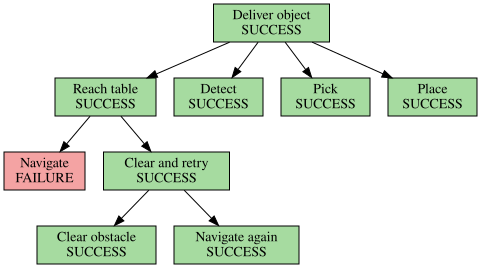

In [3]:
world = World(blocked=True)
root = mission(world)
root.tick_once()
print(asdict(world))
assert root.status is Status.SUCCESS
assert world.delivered and not world.holding
display(diagram(root))

## Step-by-step implementation
The first navigation fails. The recovery clears the obstacle and tries navigation again.
Only then can detection succeed. Picking requires a detection at the table; placing requires
an object in the gripper. Each precondition lives near its world operation rather than being
assumed by the tree. The factory keeps the policy separate from the model.

In [4]:
import inspect
print(inspect.getsource(World))
print(inspect.getsource(mission))
unprepared = World()
assert not unprepared.pick()
assert not unprepared.place()

@dataclass
class World:
    location: str = "home"
    detected: bool = False
    holding: bool = False
    delivered: bool = False
    blocked: bool = True

    def navigate(self):
        if self.blocked:
            return False
        self.location = "table"
        return True

    def clear(self):
        self.blocked = False
        return True

    def detect(self):
        self.detected = self.location == "table"
        return self.detected

    def pick(self):
        if not self.detected or self.location != "table":
            return False
        self.holding = True
        return True

    def place(self):
        if not self.holding:
            return False
        self.holding, self.delivered = False, True
        return True

def mission(world, make_leaf=leaf):
    """The same mission topology can use local functions or ROS adapters."""
    navigation = pt.composites.Selector("Reach table", memory=True, children=[
        make_leaf("Navigate", world.navigate),
     

## Interactive demonstration
Choose the initial obstacle, then execute a fresh mission. Every operation is instantaneous
in this model, so a complete mission can finish in one tick. Later ROS adapters will make
communication asynchronous while preserving the decision policy.

In [5]:
import ipywidgets as widgets

@widgets.interact(blocked=True)
def run_robot(blocked=True):
    world = World(blocked=blocked)
    root = mission(world)
    root.tick_once()
    display(diagram(root))
    print(asdict(world))

interactive(children=(Checkbox(value=True, description='blocked'), Output()), _dom_classes=('widget-interact',…

## Key observations

A tree controls operations; a world models their effects. Keeping them separate lets us replace local calls with messages later.

## Exercises

1. Add a missing-object state and a detection fallback.
2. Make navigation take three ticks without changing the mission’s ordering.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 14).

## Summary

Execution follows a chosen policy. Planning asks a different question: which actions could achieve a goal?